# Aula prática: Support Vector Machine — SVM

Ao final da prática, o aluno deverá ser capaz de:

- Treinar um modelo SVM com `scikit-learn`;
- Entender o papel dos vetores de suporte;
- Comparar modelos lineares e não lineares;
- Interpretar acurácia, matriz de confusão e relatório de classificação;
- Realizar pequenos experimentos alterando hiperparâmetros.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

np.random.seed(42)

## 2. Função auxiliar para visualizar a fronteira de decisão

A função abaixo cria uma malha de pontos no plano e usa o modelo treinado para prever a classe de cada ponto. Isso permite visualizar a região do espaço que o modelo atribui a cada classe.

Em problemas com apenas dois atributos, essa visualização ajuda bastante a entender o comportamento do SVM.

In [26]:
def plot_decision_boundary(model, X, y, title="Fronteira de decisão", show_support_vectors=True):
    # Plota a fronteira de decisão de um classificador em 2D.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=60)

    if show_support_vectors and hasattr(model, "support_vectors_"):
        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=180,
            facecolors="none",
            edgecolors="k",
            linewidths=1.8,
            label="Vetores de suporte"
        )
        plt.legend()

    plt.title(title)
    plt.xlabel("Atributo 1")
    plt.ylabel("Atributo 2")
    plt.show()

## 3. Exemplo 1 — SVM Linear em dados separáveis

Vamos começar com um problema simples: duas classes que podem ser separadas aproximadamente por uma reta.

O SVM tenta encontrar uma fronteira de decisão que separe as classes com a maior margem possível.

Os pontos mais próximos da fronteira são chamados de **vetores de suporte**. Eles são importantes porque influenciam diretamente a posição da fronteira de decisão.

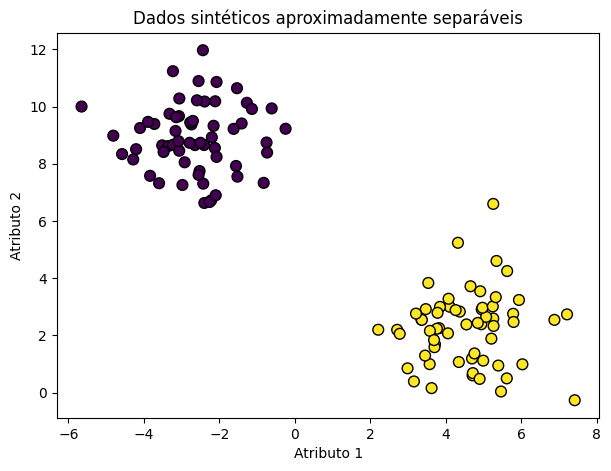

In [27]:
X, y = make_blobs(
    n_samples=120,
    centers=2,
    cluster_std=1.2,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=60)
plt.title("Dados sintéticos aproximadamente separáveis")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.show()

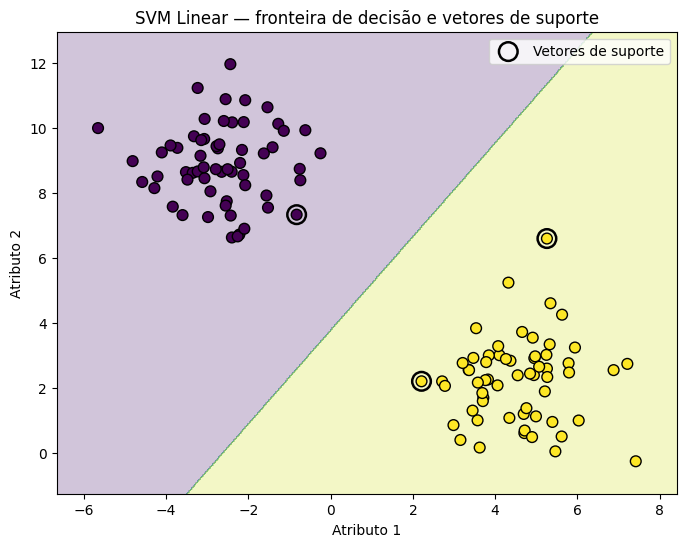

In [28]:
svm_linear = SVC(kernel="linear", C=1.0)
svm_linear.fit(X, y)

plot_decision_boundary(
    svm_linear,
    X,
    y,
    title="SVM Linear — fronteira de decisão e vetores de suporte"
)

## 4. O hiperparâmetro `C`

O parâmetro `C` controla o equilíbrio entre:

- Criar uma margem maior;
- Evitar erros de classificação nos dados de treino.

De forma simplificada:

- `C` pequeno: o modelo aceita mais erros para tentar criar uma margem maior;
- `C` grande: o modelo tenta errar menos nos dados de treino, podendo criar uma fronteira mais rígida.

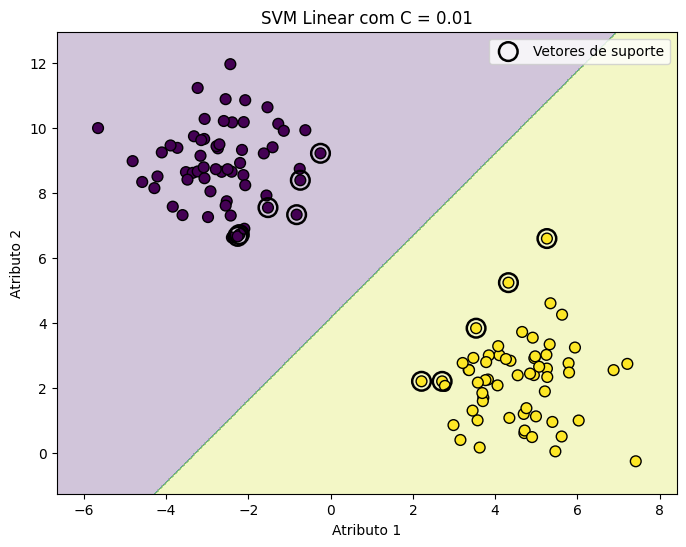

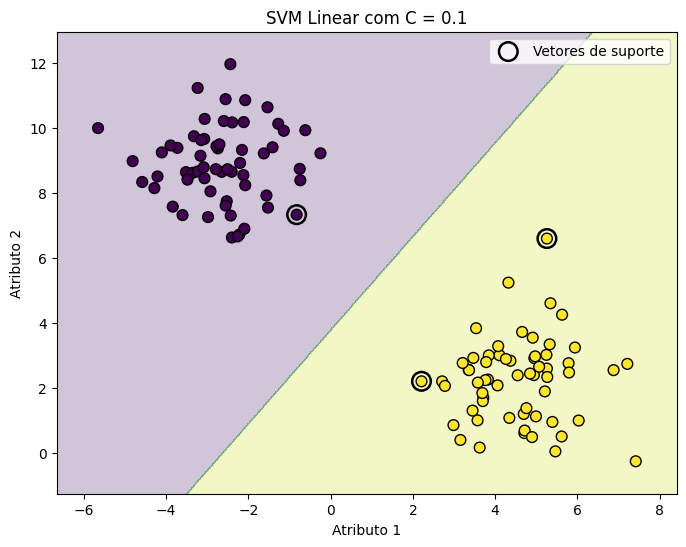

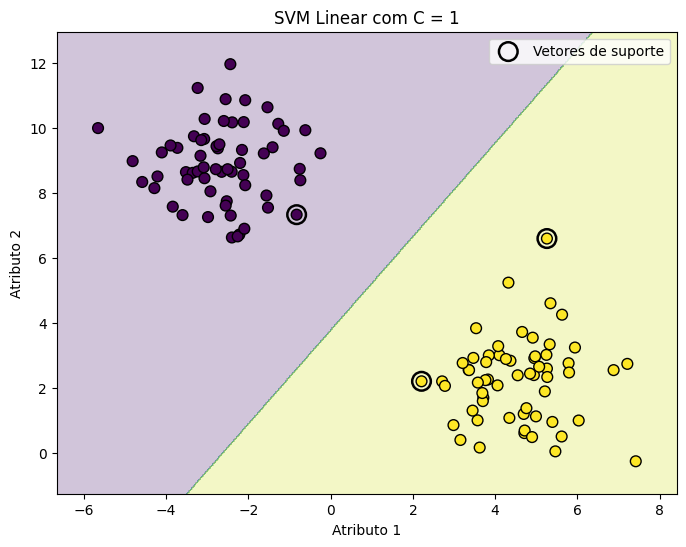

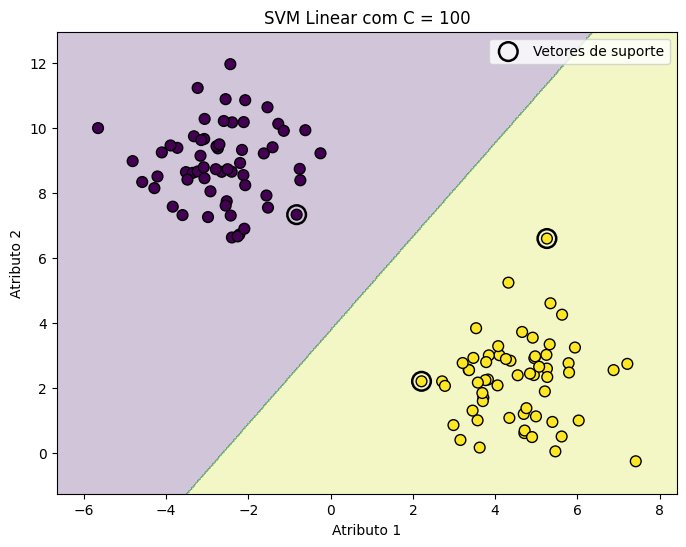

In [29]:
valores_C = [0.01, 0.1, 1, 100]

for C in valores_C:
    modelo = SVC(kernel="linear", C=C)
    modelo.fit(X, y)

    plot_decision_boundary(
        modelo,
        X,
        y,
        title=f"SVM Linear com C = {C}"
    )

## 5. Exemplo 2 — Dados não linearmente separáveis

Agora vamos criar um conjunto de dados em formato de duas luas. Esse tipo de problema não pode ser bem separado por uma única reta.

Nesse caso, um SVM linear provavelmente terá dificuldade.

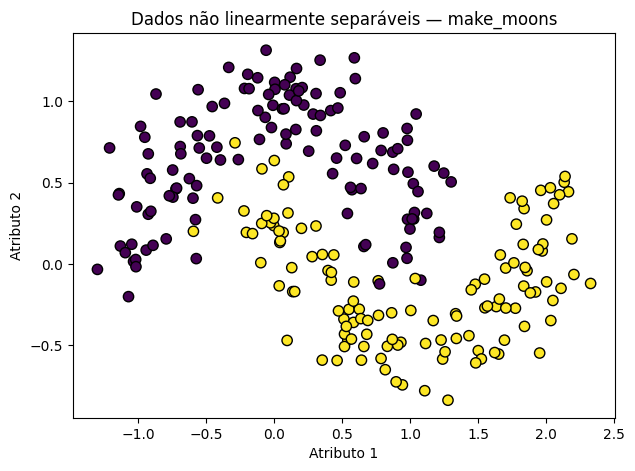

In [30]:
X_moons, y_moons = make_moons(
    n_samples=250,
    noise=0.18,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, edgecolors="k", s=55)
plt.title("Dados não linearmente separáveis — make_moons")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.show()

### 5.1 SVM Linear em dados não lineares

Vamos treinar um SVM linear e observar a limitação da fronteira reta.

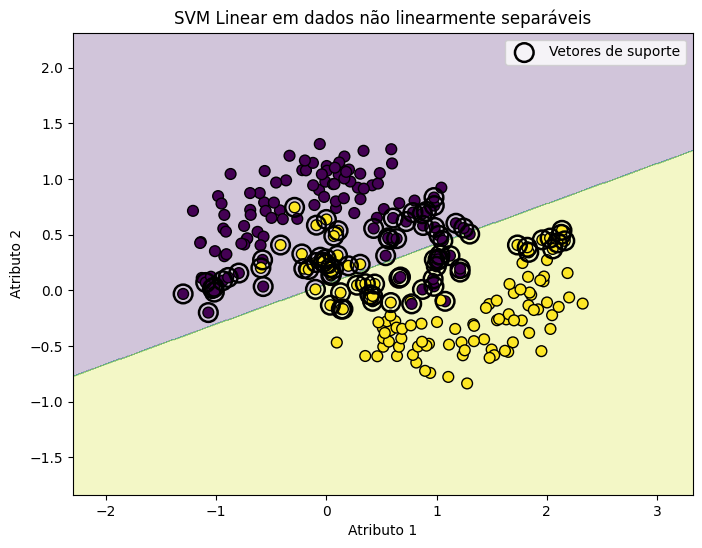

In [31]:
svm_linear_moons = SVC(kernel="linear", C=1.0)
svm_linear_moons.fit(X_moons, y_moons)

plot_decision_boundary(
    svm_linear_moons,
    X_moons,
    y_moons,
    title="SVM Linear em dados não linearmente separáveis"
)

## 6. SVM com kernel RBF

O SVM pode usar uma técnica chamada **kernel trick**, que permite criar fronteiras de decisão não lineares.

Um dos kernels mais usados é o **RBF**, também chamado de kernel gaussiano.

Ele permite que o modelo crie fronteiras curvas, adequadas para problemas em que as classes não são separáveis por uma reta.

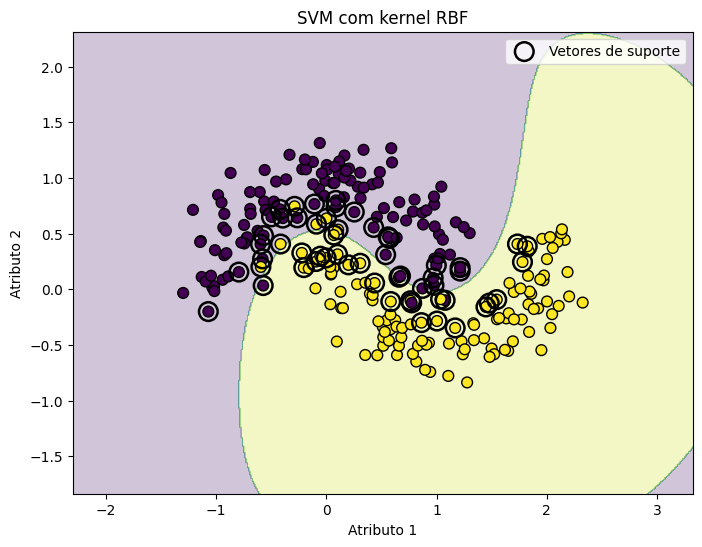

In [34]:
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf.fit(X_moons, y_moons)

plot_decision_boundary(
    svm_rbf,
    X_moons,
    y_moons,
    title="SVM com kernel RBF"
)

Compare o SVM linear com o SVM RBF.

Perguntas:

1. Qual modelo se ajustou melhor ao formato dos dados?
2. A fronteira do RBF ficou mais flexível?
3. Existe risco de o modelo ficar flexível demais?

## Respostas 
1) O modelo SVM com kernel RBF parece ter e ajustado melhor uma vez que os dados não são lineamente separaveis, fica complicado traça uma linha reta dividindo eles.
2) Sim, ela deixou de ser uma linha reta e passou a contornar os pontos
3) Sim, se ele ficar flexivel demais ele pode acabar contornando todos os pontos em vez de aprender com eles, isso fara com que ruidos passem a ser ajustados como dados legitimos.


## 7. O hiperparâmetro `gamma`

No kernel RBF, o parâmetro `gamma` controla o alcance de influência de cada ponto de treino.

De forma simplificada:

- `gamma` pequeno: cada ponto influencia uma região maior; a fronteira tende a ser mais suave;
- `gamma` grande: cada ponto influencia uma região menor; a fronteira pode ficar muito irregular.

Quando `gamma` é muito alto, o modelo pode sofrer **overfitting**, ou seja, ajustar-se demais aos dados de treino.

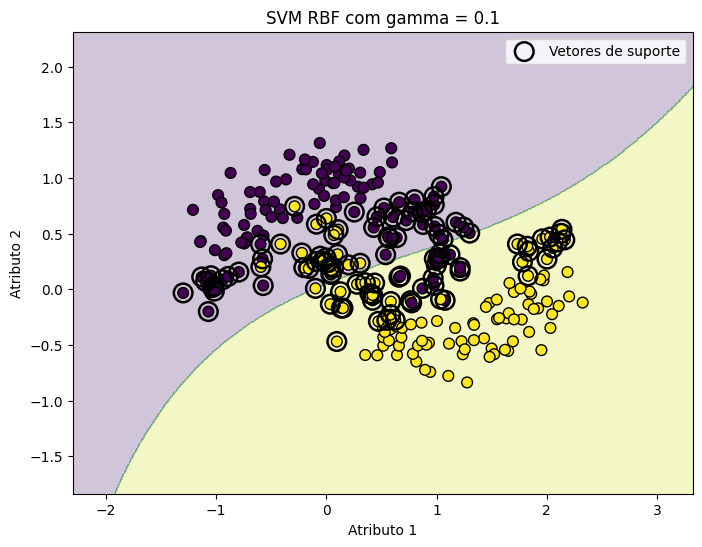

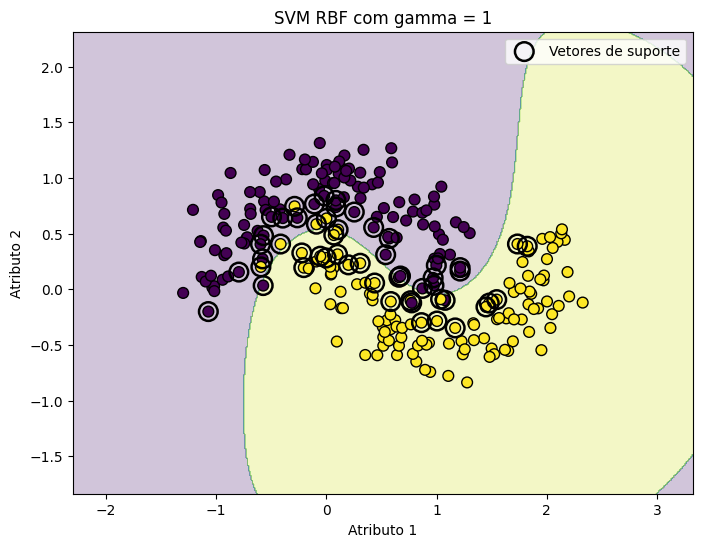

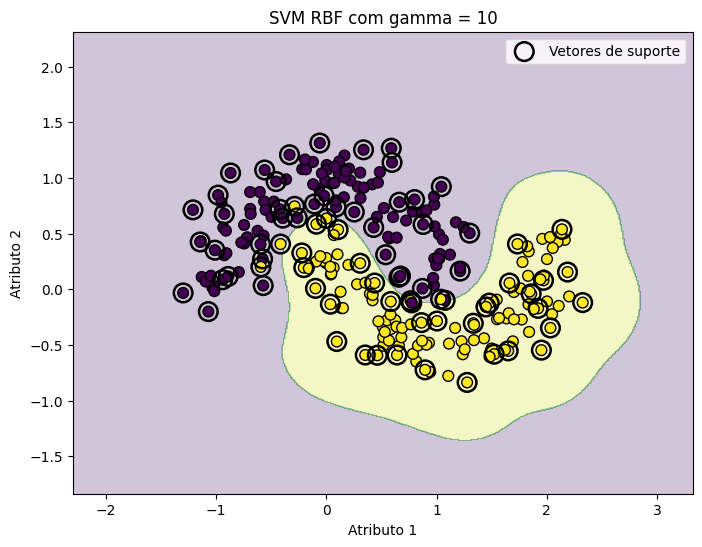

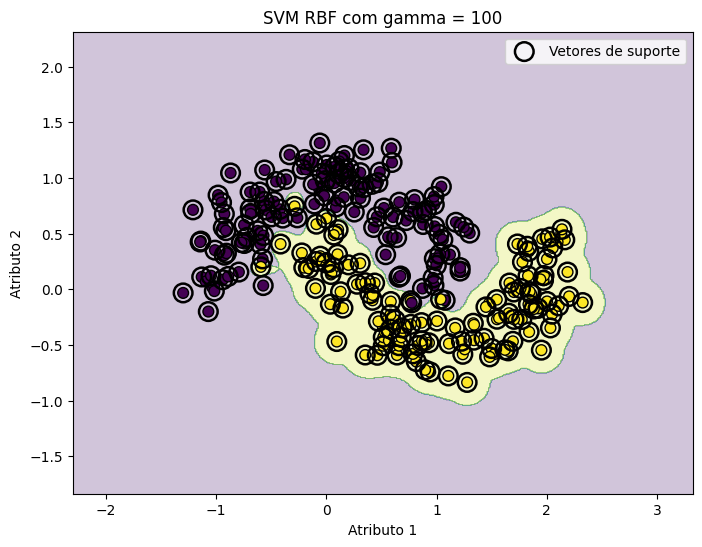

In [9]:
valores_gamma = [0.1, 1, 10, 100]

for gamma in valores_gamma:
    modelo = SVC(kernel="rbf", C=1.0, gamma=gamma)
    modelo.fit(X_moons, y_moons)

    plot_decision_boundary(
        modelo,
        X_moons,
        y_moons,
        title=f"SVM RBF com gamma = {gamma}"
    )

## 8. Exemplo 3 — Aplicando SVM no dataset Iris

Agora vamos usar um dataset clássico: o **Iris**.

O dataset Iris possui medidas de flores e três classes:

- Setosa;
- Versicolor;
- Virginica.

Para facilitar a visualização, usaremos apenas dois atributos:

- Comprimento da pétala;
- Largura da pétala.

In [10]:
iris = load_iris()

# Vamos usar apenas dois atributos para permitir visualização em 2D:
# petal length e petal width
X_iris = iris.data[:, [2, 3]]
y_iris = iris.target

print("Classes:", iris.target_names)
print("Atributos usados:", [iris.feature_names[2], iris.feature_names[3]])
print("Formato de X:", X_iris.shape)
print("Formato de y:", y_iris.shape)

Classes: ['setosa' 'versicolor' 'virginica']
Atributos usados: ['petal length (cm)', 'petal width (cm)']
Formato de X: (150, 2)
Formato de y: (150,)


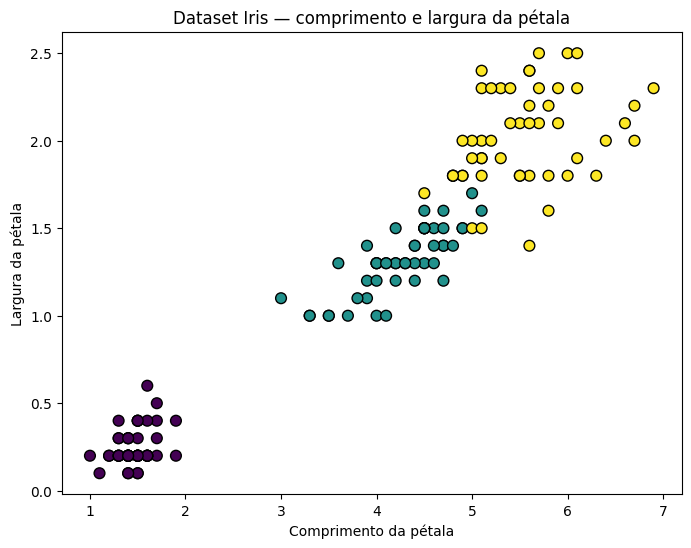

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, edgecolors="k", s=60)
plt.title("Dataset Iris — comprimento e largura da pétala")
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.show()

## 9. Divisão entre treino e teste

Vamos separar os dados em treino e teste.

O conjunto de treino será usado para aprender o modelo.

O conjunto de teste será usado para avaliar o desempenho em dados que o modelo ainda não viu.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.3,
    random_state=42,
    stratify=y_iris
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (105, 2)
Teste: (45, 2)


## 10. Importância da padronização dos dados

O SVM é sensível à escala dos atributos.

Por exemplo, se um atributo tem valores muito maiores do que outro, ele pode dominar o cálculo de distância/margem.

Por isso, é comum aplicar `StandardScaler`, que transforma os dados para terem média aproximadamente 0 e desvio padrão aproximadamente 1.

Usaremos um `Pipeline`, que encadeia duas etapas:

1. Padronização dos dados;
2. Treinamento do SVM.

In [13]:
modelo_iris = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

modelo_iris.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## 11. Avaliação do modelo

Vamos avaliar o modelo usando:

- Acurácia;
- Matriz de confusão;
- Relatório de classificação com precisão, revocação e F1-score.

In [14]:
y_pred = modelo_iris.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no teste: {acc:.4f}")

Acurácia no teste: 0.9111


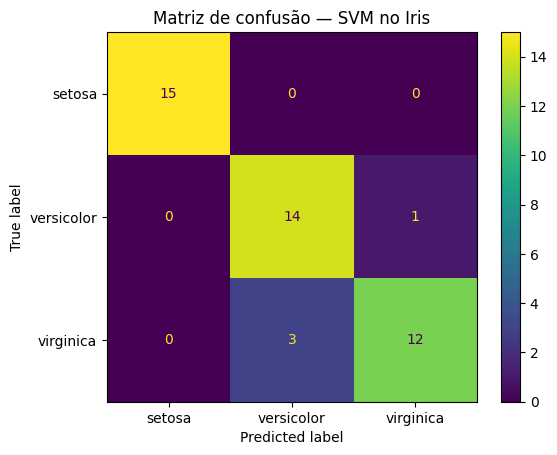

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Matriz de confusão — SVM no Iris")
plt.show()

In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## 12. Visualizando a fronteira de decisão no Iris

Como usamos apenas dois atributos, podemos visualizar a fronteira de decisão do modelo.

Atenção: o modelo foi treinado com padronização. Para visualizar corretamente, criaremos uma função adaptada para modelos com `Pipeline`.

In [18]:
def plot_decision_boundary_pipeline(model, X, y, title="Fronteira de decisão"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=60)
    plt.title(title)
    plt.xlabel("Comprimento da pétala")
    plt.ylabel("Largura da pétala")
    plt.show()

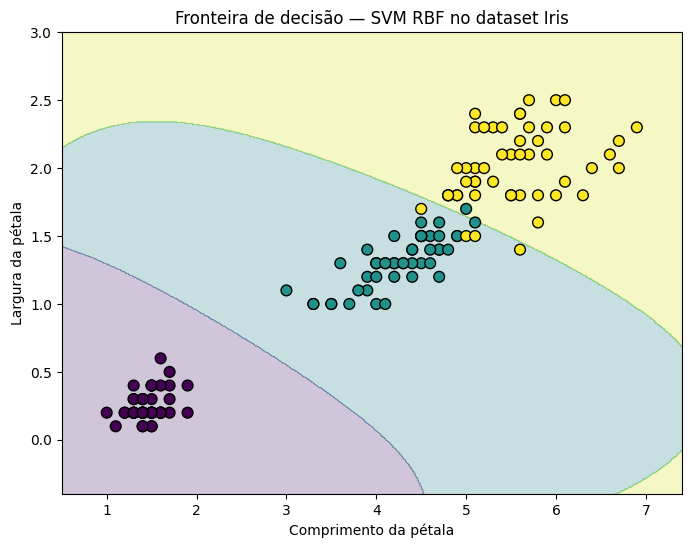

In [19]:
plot_decision_boundary_pipeline(
    modelo_iris,
    X_iris,
    y_iris,
    title="Fronteira de decisão — SVM RBF no dataset Iris"
)

## 13. Comparando diferentes kernels

Vamos comparar três kernels:

- `linear`: cria uma fronteira linear;
- `poly`: cria uma fronteira polinomial;
- `rbf`: cria uma fronteira não linear mais flexível.

Kernel: linear
Acurácia: 0.9111111111111111
----------------------------------------


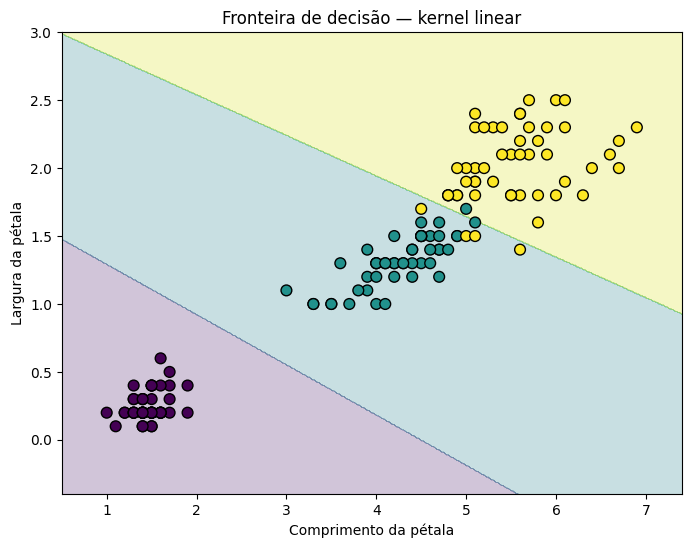

Kernel: poly
Acurácia: 0.9111111111111111
----------------------------------------


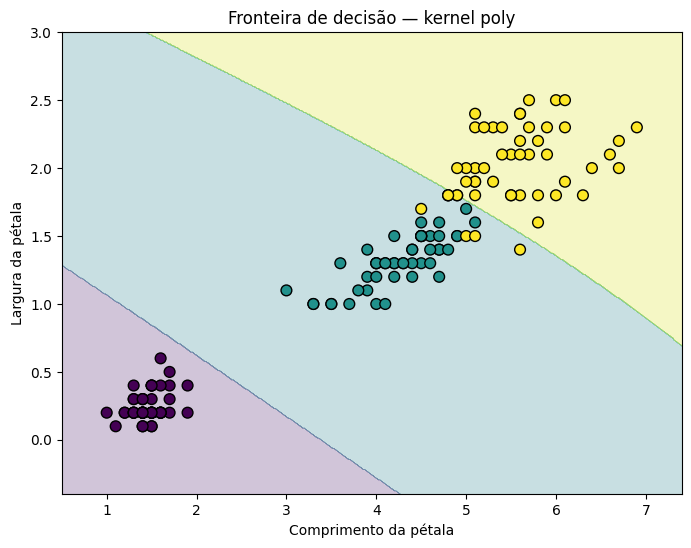

Kernel: rbf
Acurácia: 0.9111111111111111
----------------------------------------


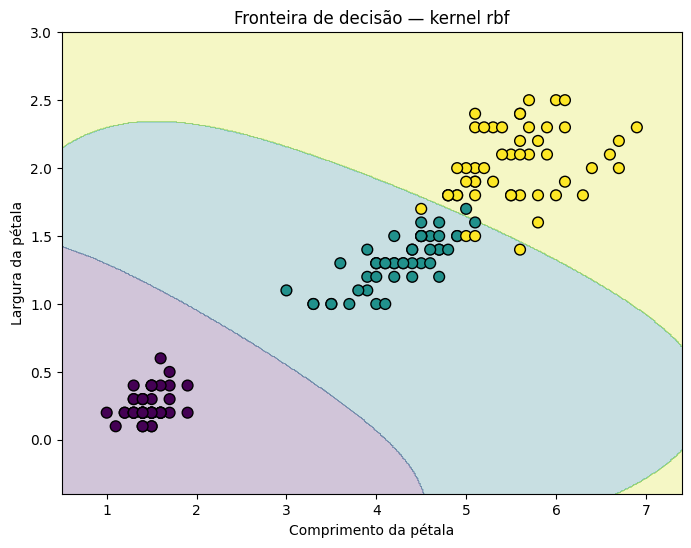

In [21]:
kernels = ["linear", "poly", "rbf"]

for kernel in kernels:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=kernel, C=1.0, gamma="scale"))
    ])

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    print("Kernel:", kernel)
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("-" * 40)

    plot_decision_boundary_pipeline(
        modelo,
        X_iris,
        y_iris,
        title=f"Fronteira de decisão — kernel {kernel}"
    )

## 14. Busca simples de hiperparâmetros com GridSearchCV

Na prática, não sabemos antecipadamente qual valor de `C`, `gamma` ou kernel será melhor.

Podemos testar várias combinações usando validação cruzada com `GridSearchCV`.

In [22]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": [0.01, 0.1, 1, 10]
    }
]

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid.best_params_)
print()
print(f"Melhor acurácia média na validação cruzada: {grid.best_score_:.4f}")

Melhores parâmetros:
{'svm__C': 0.1, 'svm__kernel': 'linear'}

Melhor acurácia média na validação cruzada: 0.9810


In [23]:
melhor_modelo = grid.best_estimator_
y_pred_best = melhor_modelo.predict(X_test)

print(f"Acurácia do melhor modelo no teste: {accuracy_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(
    y_test,
    y_pred_best,
    target_names=iris.target_names
))

Acurácia do melhor modelo no teste: 0.9111

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



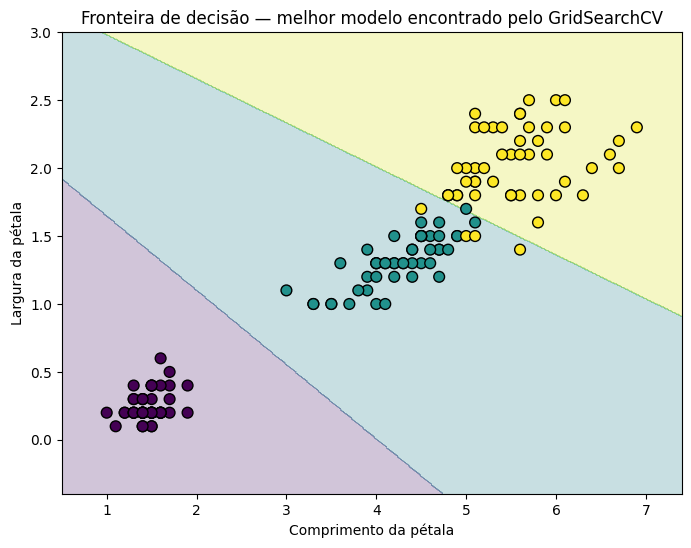

In [24]:
plot_decision_boundary_pipeline(
    melhor_modelo,
    X_iris,
    y_iris,
    title="Fronteira de decisão — melhor modelo encontrado pelo GridSearchCV"
)

## 15. Exercícios

### Exercício 1 — Alterando `C`

No dataset `make_moons`, teste os seguintes valores de `C` usando kernel RBF:

```python
C = 0.01, 0.1, 1, 10, 100
```

Responda:

1. O que acontece com a fronteira de decisão?
2. O modelo parece mais simples ou mais complexo quando `C` aumenta?
3. Em qual valor o modelo parece generalizar melhor?

---

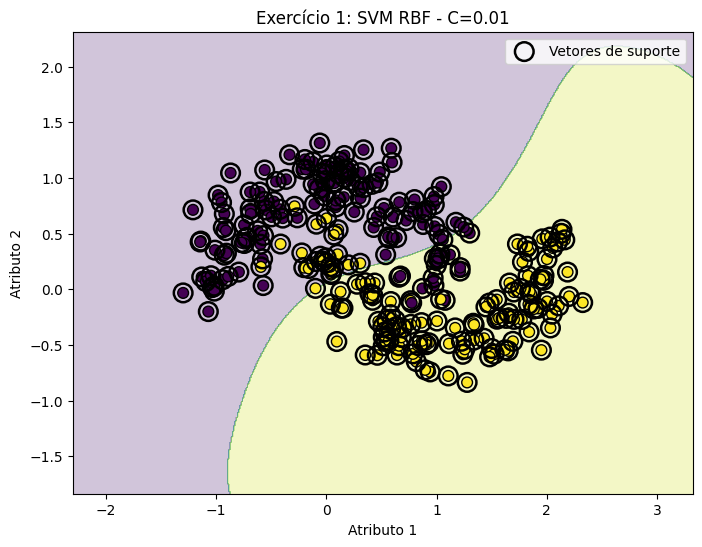

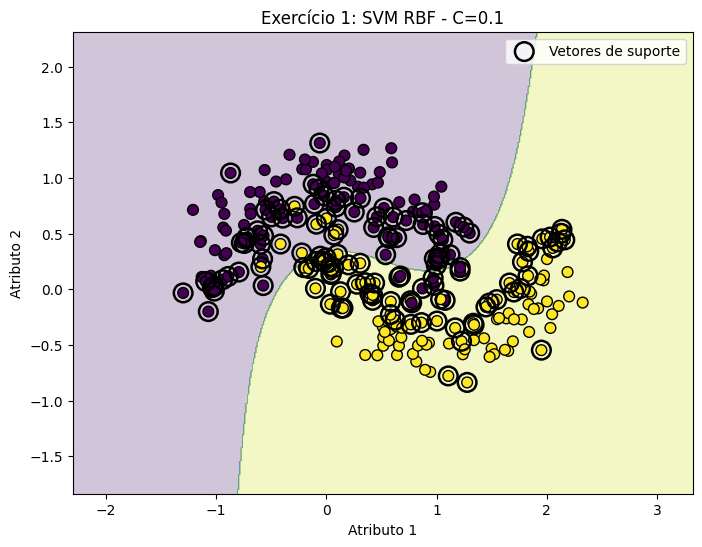

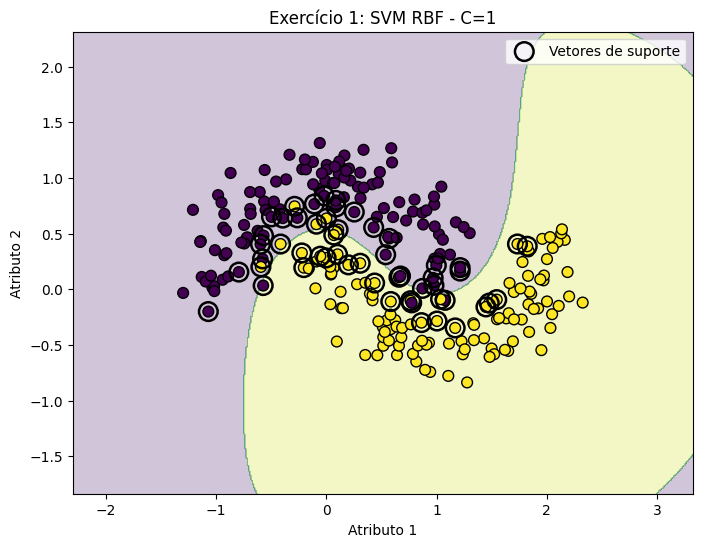

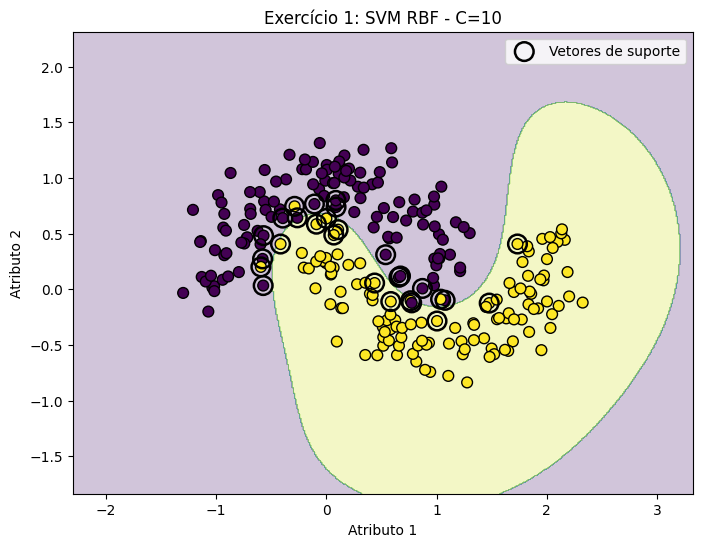

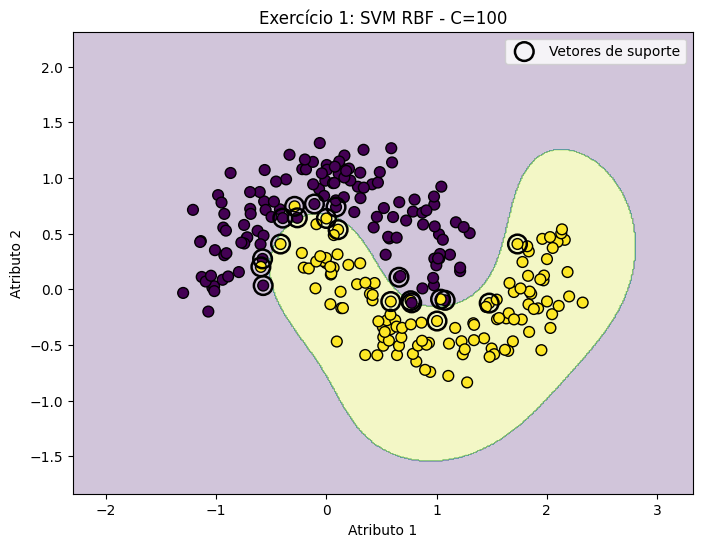

In [35]:
C = [0.01, 0.1, 1, 10, 100]
for i in C:
    modelo_ex1 = SVC(kernel="rbf", C=i, gamma=1)
    modelo_ex1.fit(X_moons, y_moons)

    plot_decision_boundary(
        modelo_ex1, 
        X_moons, 
        y_moons, 
        title=f"Exercício 1: SVM RBF - C={i}"
    )

## Respostas
1) Com valores menoras a fronteira é mais suave, já a medida que esse valor aumenta, ela tenta classificar corretamente todos os pontos
2) Sim, ele se torna mais complexo e rigido em como trata os dados
3) Creio que o c = 1 ou 10 foi o que teve melhor equilibrio 



### Exercício 2 — Alterando `gamma`

No dataset `make_moons`, teste os seguintes valores de `gamma`:

```python
gamma = 0.01, 0.1, 1, 10, 100
```

Responda:

1. O que acontece quando `gamma` é muito baixo?
2. O que acontece quando `gamma` é muito alto?
3. Qual valor parece produzir uma fronteira mais equilibrada?

---

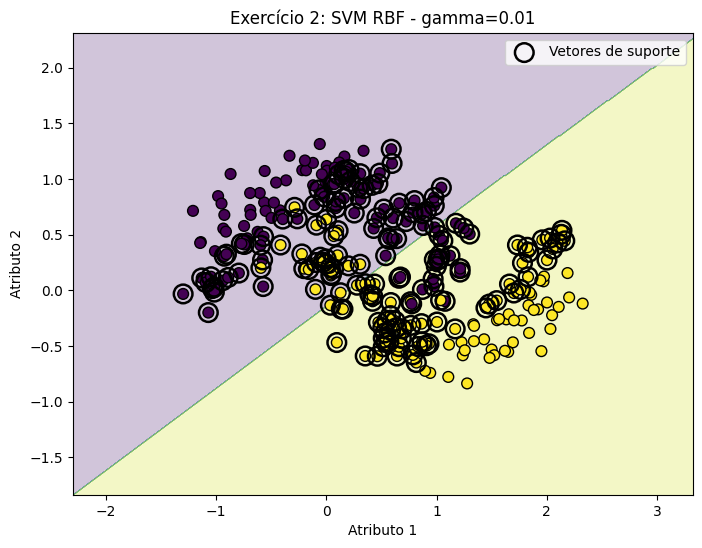

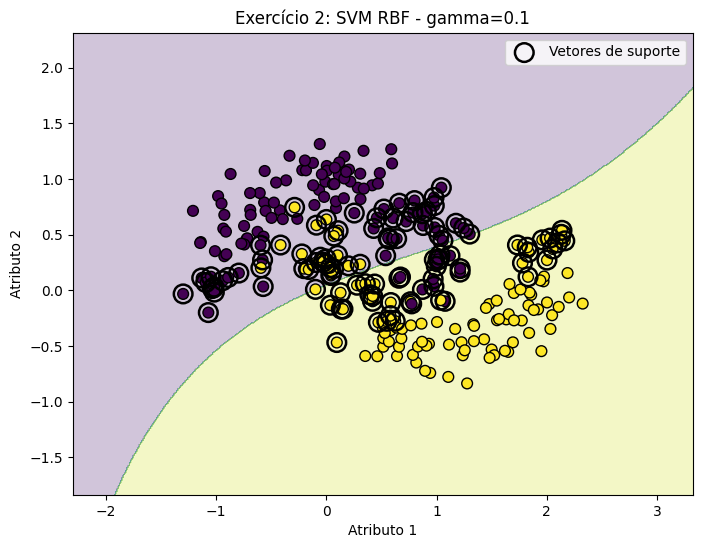

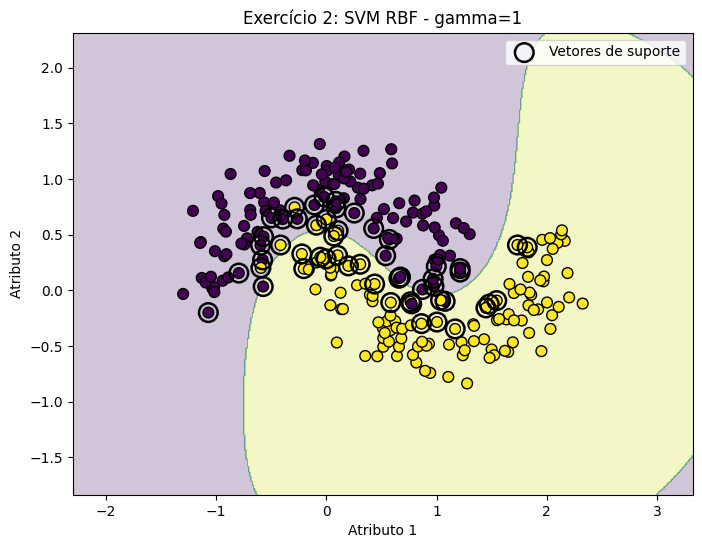

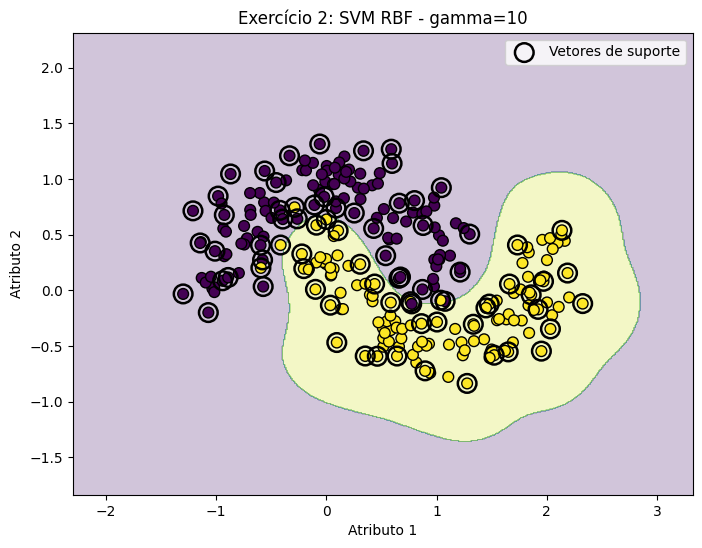

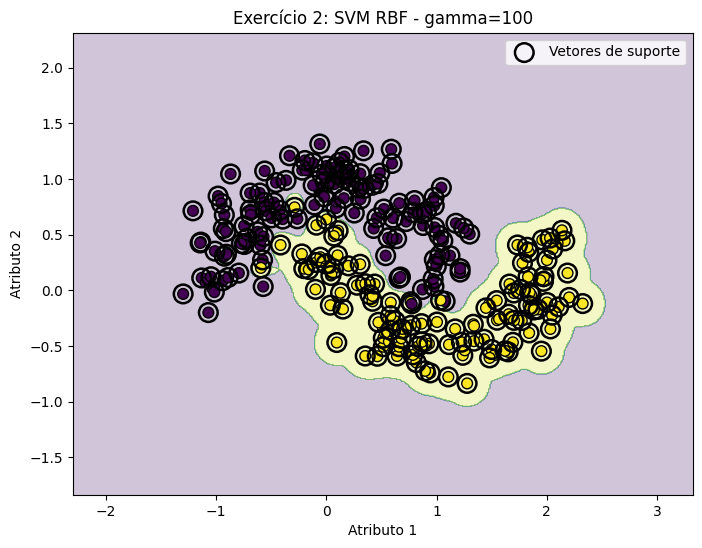

In [36]:
GAMA = [0.01, 0.1, 1, 10, 100]
for i in GAMA:
    modelo_ex1 = SVC(kernel="rbf", C=1, gamma=i)
    modelo_ex1.fit(X_moons, y_moons)

    plot_decision_boundary(
        modelo_ex1, 
        X_moons, 
        y_moons, 
        title=f"Exercício 2: SVM RBF - gamma={i}"
    )

# Resposta
1) A area de influencia de cada ponto é tão grande que a região se reduz praticamente a uma reta
2) A influencia agora passa a ser muito pequena, quebrando a fronteira de desisão e formando ilhas. Aqui o modelo praticamente decorou esses dados e não aprendeu nada, o que caracterisa um overfitting
3) O melhor valor parece ser o Gamma = 1

### Exercício 3 — Dataset Iris com todos os atributos

Até agora usamos apenas dois atributos do Iris para facilitar a visualização.

Agora treine um SVM usando os quatro atributos do dataset Iris.

Dica:

```python
X = iris.data
Y = iris.target
```

Compare a acurácia com a versão que usou apenas dois atributos.

---


In [37]:
iris = load_iris()
X = iris.data 
y = iris.target

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Pipeline
modelo_iris_completo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# Treinando
modelo_iris_completo.fit(X_train, y_train)

# Avaliando 
y_pred = modelo_iris_completo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia do SVM usando os 4 atributos do Iris: {acuracia:.4f}")

Acurácia do SVM usando os 4 atributos do Iris: 0.9333


### Resposta
A acurácia aumentou de 0.91 para 0.93 com o aumento no numero de atributos

### Exercício 4 — Comparação com KNN ou Árvore de Decisão

Treine outro algoritmo de classificação, como KNN ou Árvore de Decisão, e compare com o SVM.

Responda:

1. Qual modelo obteve maior acurácia?
2. Qual modelo parece mais simples de explicar?
3. Qual modelo parece mais sensível aos hiperparâmetros?

-----------------

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# KNN
modelo_knn = KNeighborsClassifier(n_neighbors=3)
modelo_knn.fit(X_train, y_train)

y_pred_knn = modelo_knn.predict(X_test)
acuracia_knn = accuracy_score(y_test, y_pred_knn)
print(f"Acurácia do KNN: {acuracia_knn:.4f}")

# Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train, y_train)

y_pred_arvore = modelo_arvore.predict(X_test)
acuracia_arvore = accuracy_score(y_test, y_pred_arvore)
print(f"Acurácia da Árvore de Decisão: {acuracia_arvore:.4f}")

# SVM
print(f"Acurácia do SVM: {acuracia:.4f}")

Acurácia do KNN: 0.9556
Acurácia da Árvore de Decisão: 0.9333
Acurácia do SVM: 0.9333


1) O KNN teve maior acurácia, em comparação com os outros 2 que emparatam em 2º.
2) Arvores de decisão são mais simples de explicar, pq é bem direto mostrar as regras visuais que elas criam, tipo, se uma petala for maior que X cm, classifique como Y.
3) SVM, ele é muito sencivel aos valores de C e Gamma, podendo variar de uma precisão de 93% para quase nada apenas com o ajuste minimo desses 2 parametros.

## 16. Código-base para os exercícios

Podem usar o código abaixo como ponto de partida para os experimentos.

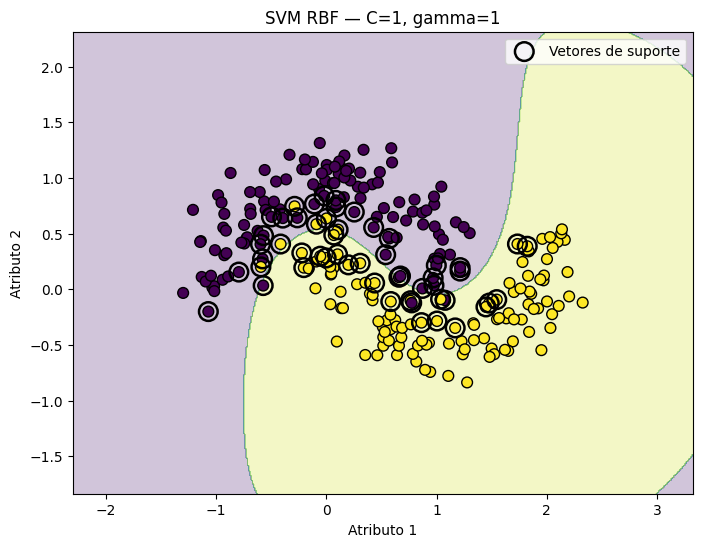

In [23]:
# Código-base para experimentar C e gamma no make_moons

C_escolhido = 1
gamma_escolhido = 1

modelo_exercicio = SVC(
    kernel="rbf",
    C=C_escolhido,
    gamma=gamma_escolhido
)

modelo_exercicio.fit(X_moons, y_moons)

plot_decision_boundary(
    modelo_exercicio,
    X_moons,
    y_moons,
    title=f"SVM RBF — C={C_escolhido}, gamma={gamma_escolhido}"
)

## 17. Conclusões da aula

Nesta prática, vimos que:

- O SVM busca separar classes criando uma margem entre elas;
- Os vetores de suporte são os pontos mais importantes para definir a fronteira;
- O kernel linear funciona bem quando as classes são aproximadamente separáveis por uma reta;
- O kernel RBF permite fronteiras não lineares;
- `C` controla o quanto o modelo penaliza erros no treinamento;
- `gamma` controla a influência local dos pontos no kernel RBF;
- A padronização dos dados é muito importante para o SVM;
- A escolha de hiperparâmetros pode ser feita com validação cruzada.
